In [1]:

import numpy
# %pylab

import pandas

# dato che ci serve matplotlib useremo python 2
from matplotlib import pyplot

%matplotlib inline


In [3]:

dataframe = pandas.read_csv("../data/cell_towers_diff-2016012100.csv")

# coordinate = dataframe[['lon', 'lat']]

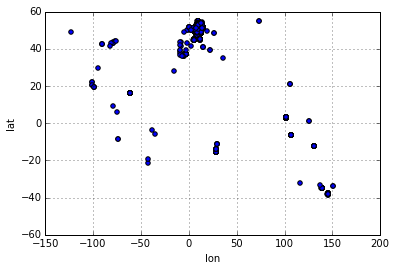

In [4]:
dataframe.plot(kind="scatter", x="lon", y="lat")

# pyplot.show()

## golocalizzazione

In [5]:
# import math

def euclideanDistace(x,y):
    return numpy.sqrt(numpy.square(x) + numpy.square(y))

In [6]:
import geopy # TODO AttributeError: 'module' object has no attribute 'distance'
from geopy import distance, geocoders

# distanze in km
# geopy.distance.vincenty(A, B) # su sferoide oblato
# geopy.distance.great_circle(A, B) # sulla sfera

# punti di prova
# A = (41.49008, -71.312796)
# B = (41.499498, -81.695391)

def geolocate(place): # string
    """
    return coordinates for addresses and toponyms
    """
    geolocator = geopy.geocoders.Nominatim()
    location = geolocator.geocode(place)
    # i dati si danno in (latitudine, longitudine), ma vanno intesi come (y, x)
    # ovvero vanno visualizzati come x=longitudine, y=latitudine
    return (location.latitude, location.longitude) # coordinate
    
def geodesicDistance(A, B = geolocate("Colosseo")):
    """
    return the Vincenty's geodesic distance in meters
    default place = Colosseum
    """
    # colosseo = (41.890183, 12.492369)
    return geopy.distance.vincenty(A, B).meters

def isInRome(place):
    """
    return True if the place is less than 10 km away from Colosseum
    """
    raggioRaccordoAnulare = 10000 # in metri
    return geodesicDistance(place) <= raggioRaccordoAnulare

In [7]:
name = "Sapienza, Roma"

print(geodesicDistance(geolocate(name)))
print(isInRome(geolocate(name)))

2099.29518992
True


In [8]:
colosseo = geopy.point.Point(41.890183, 12.492369)

# TODO fare map con coordinate nel datagrame

In [9]:
# import mpl_toolkits.basemap
# from mpl_toolkits.basemap import Basemap

# mappa = Basemap(projection='stere',lat_0=41.890183,lon_0=12.492369,resolution='l')
# mappa.drawcoastlines(linewidth=0.25)
# mappa.drawcountries(linewidth=0.25)
# mappa.fillcontinents(color='coral',lake_color='aqua')
# mappa.drawmapboundary(fill_color='aqua')
# mappa.drawmeridians(numpy.arange(0,360,30))
# mappa.drawparallels(numpy.arange(-90,90,30))

# x, y = map(lons*180./np.pi, lats*180./np.pi)
# cs = map.contour(x,y,wave+mean,15,linewidths=1.5)
# plt.title('contour lines over filled continent background')
# plt.show()



In [10]:
# m = Basemap(width=100000,height=100000,projection='lcc',resolution=None,lat_0=41.890183,lon_0=12.492369)
#m.drawcoastlines()
#m.drawmapboundary(fill_color='aqua')
#m.fillcontinents(color='coral',lake_color='aqua')
# m.bluemarble()
## m.shadedrelief()

# resolution: c (crude), l (low), i (intermediate), h (high), f (full)

# plt.show()

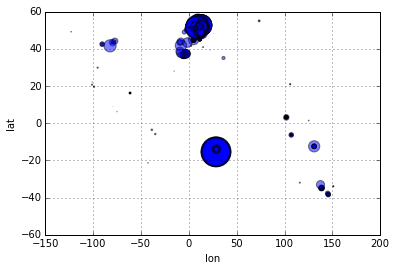

In [12]:
copertura = dataframe[["range"]]

dataframe.plot(kind="scatter", x="lon", y="lat", s=copertura/1000, alpha=0.5) # TODO

# pyplot.show()

## selezione dei dati

il filtraggio viene inizialmente fatto per mobile country code (Italy)
```python
mcc == 222
```
e successivamente vengono scartati i valori ritenuti inaffidabili, ovvero con soltanto una rilevazione
```python
samples > 1
```

In [13]:
isInItaly = dataframe.mcc == 222

isReliable = dataframe.samples > 1

# Crit3 = isInRome((dataframe.lat, dataframe.lon))

# AllCriteria = isInItaly & isReliable & Crit3

# dataframe[AllCriteria]

italia = dataframe[isInItaly & isReliable]

# TODO riordinare gli indici levando i buchi

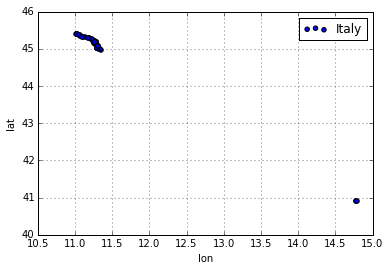

In [14]:
italia.plot(kind="scatter", x="lon", y="lat", label="Italy")

# pyplot.show()

Iuri ha fatto la selezione su Roma e ha creato un nuovo file csv  
TODO integrare il suo codice

```python
# isInRome((dataframe.lat, dataframe.lon))

italyDataframe["lat"].apply(sum)

dataframe["distanze"] = arrayDistanzeCalcolate

.apply()
.applymap()
.resample()
.transform()
.groupby

code_groups[['data']].transform(sum)
```

## TODO Capocci

<ul>
<li><input type="checkbox" checked>dati MLS</li>
<li><input type="checkbox" checked>filtro Roma</li>
<li><input type="checkbox" checked>grafo</li>
<li><input type="checkbox" checked>distribuzione del grado P(k)</li>
<li><input type="checkbox" checked>dati disaggregati per compagnia, canale radio, ecc</li>
<li><input type="checkbox" checked>soglia percolativa</li>
</ul>

## Creazione del grafo con NetworkX

TODO si può anche fare un grafo pesato sull'intensità del segnale  

TODO:

* mettere sfondo allo scatterplot con mappa terrestre
(farlo con le API di Google Maps o con quelle di OpenStreetMaps)

* provare API grafi per fare grafo delle antenne
* aggiungere colonna database per distanze e coperture antenne



In [16]:
import networkx

G = networkx.Graph()
G.add_node("Fede")
G.add_node("Iuri")
G.add_edge(1,2)
G.add_edge('a','b')
G.add_edge('a','c')
G.add_edge('c','d')
G.add_edge('c','e')
G.add_edge('c','f')
G.add_edge('a','d')


['a', 1, 'Fede', 'b', 'e', 'Iuri', 'f', 'c', 2, 'd']
[('a', 'c'), ('a', 'b'), ('a', 'd'), (1, 2), ('e', 'c'), ('f', 'c'), ('c', 'd')]


{1: array([ 0.21662852,  0.08226044]),
 2: array([ 0.65575623,  0.01664105]),
 'Fede': array([ 0.46162538,  0.        ]),
 'Iuri': array([ 0.        ,  0.64255976]),
 'a': array([ 0.83869163,  0.48669322]),
 'b': array([ 0.51991337,  0.41750826]),
 'c': array([ 0.78873727,  0.84999116]),
 'd': array([ 0.98855146,  0.61042264]),
 'e': array([ 0.37692387,  1.        ]),
 'f': array([ 0.62381488,  0.99543277])}

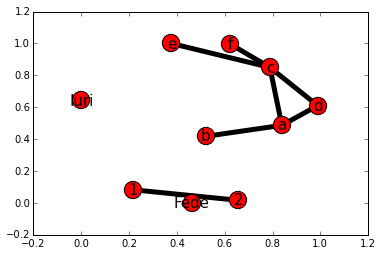

In [17]:
print(G.nodes())
print(G.edges())
position=networkx.spring_layout(G)
networkx.draw_networkx_nodes(G,position,node_size=300)
networkx.draw_networkx_edges(G,position,width=5)
networkx.draw_networkx_labels(G,position,font_size=15,font_family='sans-serif')
# pyplot.axis("off")

position


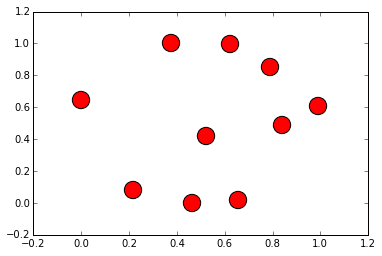

In [18]:
H=networkx.path_graph(10)
networkx.draw_networkx_nodes(G,position,node_size=300)

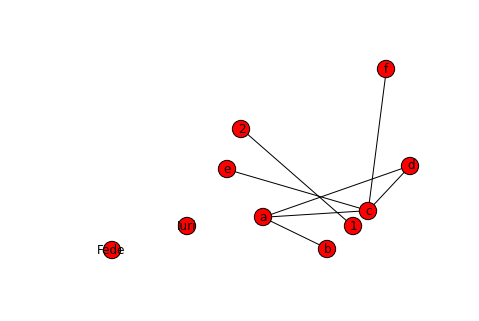

In [19]:
networkx.draw_random(G)

In [20]:
dataframePiccolo = italia[0:10]
dataframePiccolo["cell"]

3251    87079387
3255    87059907
3355    87031990
3411    86376981
3577    87058264
3578    87036959
3599    87069990
3600    87072795
3611    87058318
3612    87036956
Name: cell, dtype: int64

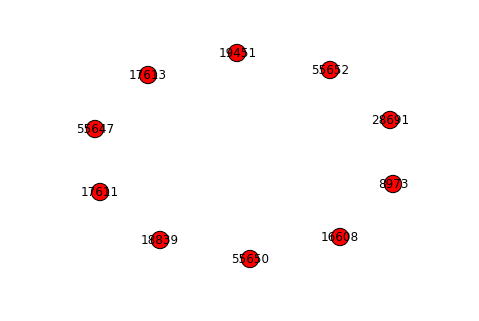

In [21]:
dataframePiccolo = roma[0:10]

grafoPiccolo = networkx.Graph()
grafoPiccolo.add_nodes_from(dataframePiccolo["cell"])
# grafoPiccolo.add_nodes_from(dataframePiccolo.iterrows())
# grafoPiccolo.add_nodes_from(dataframePiccolo.itertuples())
networkx.draw(grafoPiccolo)

In [22]:
import numpy
matriceDiAdiacenza = numpy.zeros((10,10), dtype=int)
# le matrici hanno indici che partono da zero
matriceDiAdiacenza

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [23]:


#dataframe = pandas.read_csv("../Siscomp_datas/cell_towers.csv")
romaPiccolo = roma[0:50]
#dataframe

#celle = dataframe[['cell', 'lat', 'lon', 'range']].values
#print celle
coordinate = romaPiccolo[['lat', 'lon']].values
raggio = romaPiccolo['range'].values

#print coordinate
#print raggio

def geodesicDistance(A, B):
    return geopy.distance.vincenty(A, B).meters

def sommaRange(A, B):
    return A+B

def sonoLinkati(A, rangeA, B, rangeB):
    return geodesicDistance(A, B) <= sommaRange(rangeA, rangeB)

def linkVettori(rigA, rigB):
    return sonoLinkati((rigA['lat'], rigA['lon']), rigA['range'], (rigB['lat'], rigB['lon']), rigB['range'])

dimensioni = raggio.size
a = numpy.zeros((dimensioni,dimensioni), dtype=int)
# print a

for i in xrange(raggio.size):
    for j in xrange(raggio.size):
        if geodesicDistance(coordinate[i], coordinate[j]) <= raggio[i] + raggio[j]:
            a[i,j] = 1
        if (i == j):
            a[i,j] = 0
print a


#for i in celle:
#    for j in celle:
#        if linkVettori(i, j):
#            a[i,j] = 1

            
#ridotto = dataframe[['cell', 'lat', 'lon', 'range']]        
#b = numpy.zeros((50,50))

#for i in ridotto.iterrows():
#    for j in ridotto.iterrows():
#        if linkVettori(i, j):
#            a[ridotto["index"],ridotto["index"]] = 1


[[0 0 1 ..., 1 1 1]
 [0 0 0 ..., 0 0 0]
 [1 0 0 ..., 0 0 0]
 ..., 
 [1 0 0 ..., 0 1 1]
 [1 0 0 ..., 1 0 1]
 [1 0 0 ..., 1 1 0]]


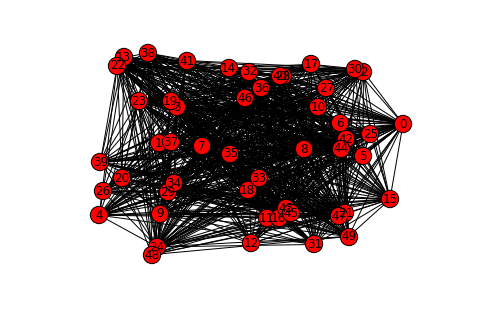

In [24]:
# A = numpy.reshape(numpy.random.random_integers(0,1,size=100),(10,10))
# D = networkx.DiGraph(A)

# networkx.draw(D)

F50 = networkx.Graph(a)


# position=networkx.spring_layout(F50)
# networkx.draw(F50)

# networkx.draw_networkx_nodes(F50,position,node_size=300)
# networkx.draw_networkx_edges(F50,position,width=5)
# networkx.draw_networkx_labels(F50,position,font_size=15,font_family='sans-serif')
networkx.draw_random(F50)

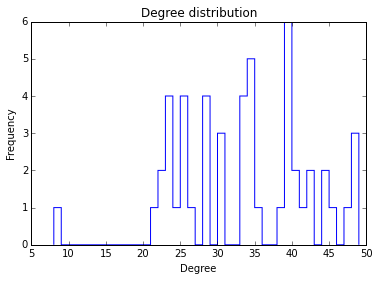

In [25]:
# networkx.degree(F50)
grado = F50.degree().values()

def degreeDistribution(gradi):
    pyplot.hist(gradi, bins=max(gradi)-min(gradi), histtype='step')
    pyplot.title('Degree distribution')
    pyplot.xlabel("Degree")
    pyplot.ylabel("Frequency")
    # return
    # histtype='bar', alpha=0.5
    # bins=max(grado)-min(grado)

distribuzione = degreeDistribution(grado)


## Distribuzione dei raggi di copertura delle antenne

TODO fare il fit esponenziale

ci sono molte antenne "piccole" e poche antenne "grandi"

ci sono pure alcune antenne dal raggio di copertura gigante $\sim 10 Km$
(ovvero quanto tutto il raggio del Grande Raccordo Anulare e quindi di tutto il nostro data sample)

probabilmente questi saranno degli hub se la nostra rete risulterà essere complessa

20341


20341.0

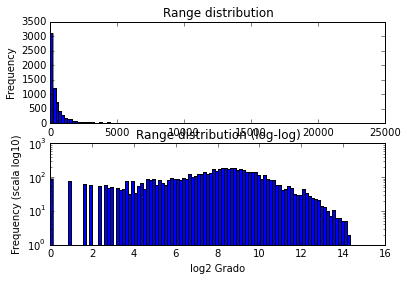

In [40]:
import numpy

# raggi = roma['range'].values

raggiPositivi = roma.range >= 1

raggiBuoni = roma[raggiPositivi].range.values

#distribuzioneRange = pyplot.hist(raggi, 100)

#distribuzioneRangeLogLog = pyplot.hist(numpy.log2(raggiBuoni), 100, log=True)

raggi = roma[raggiPositivi].range.values

pyplot.figure(1)
pyplot.subplot(211)
distribuzioneRange = pyplot.hist(raggi,bins=100)
pyplot.title('Range distribution')
pyplot.xlabel("Degree")
pyplot.ylabel("Frequency")

pyplot.subplot(212)
distribuzioneRangeLogLog = pyplot.hist(numpy.log2(raggiBuoni), 100, log=True)
pyplot.title('Range distribution (log-log)')
pyplot.xlabel("log2 Grado")
pyplot.ylabel("Frequency (scala log10)")

massimoRange = max(distribuzioneRange[1])
massimoRange


#numpy.nan in raggi
#min(raggi)

# TODO vedere se l'antenna di massimo range sta su Monte Mario
# TODO fare mappa geografica delle antenne di range gigante per vedere dove sono messe

TODO fare lo scatterplot georeferenziato con  

basemap e cartopy:

http://matplotlib.org/basemap/
http://scitools.org.uk/cartopy/docs/latest/
http://scitools.org.uk/cartopy/docs/latest/gallery.html

oppure con le API o bindings per OperStreetMaps o Google Maps


## multiprocessing e calcolo parallelo



In [27]:
from joblib import Parallel, delayed  
import multiprocessing

inputs = range(10)  
def processInput(i):  
    return i * i


num_cores = multiprocessing.cpu_count()

results = Parallel(n_jobs=num_cores)(delayed(processInput)(i) for i in inputs)
results

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]

In [28]:
def matriceSuperiore(datiCoordinate, datiRaggi):
    a = numpy.zeros((datiRaggi.size,datiRaggi.size))
    for i in xrange(datiRaggi.size):
        for j in xrange(datiRaggi.size-i-1):
            if geodesicDistance(datiCoordinate[i], datiCoordinate[j+i+1]) <= datiRaggi[i] + datiRaggi[j+i+1]:
#            if geodesicDistance(datiCoordinate[i], datiCoordinate[j+i+1]) <= datiRaggi[i] + datiRaggi[j+i+1]:
                a[i,j+i+1] = 1
                a[j+i+1,i] = 1
    return a


In [29]:
# iterare su una matrice numpy

def matriceSimilSimmetrica(N):
    """
    crea una matrice triangolare bassa
    (per adesso includendo la diagonale, per seplicità)
    """
    #a = range(N)
    #return [range(i+1) for i in a]
    
    #bucket = [0] * N
    for i in range(N):
        j = i + 1
        a[i] = [0] * j
    return a

b = numpy.zeros((5,5), dtype=int)

for i in numpy.nditer(b): print i

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [30]:
#tri = numpy.zeros((10, 10))
#dm = tri[numpy.triu_indices(10, 1)]
#dm

#tri[(1,2), (4,5)]

triangolo = matriceSimilSimmetrica(N)
triangolo
# listofzeros = [0] * n

NameError: name 'N' is not defined

<img src="https://i.imgflip.com/zjptw.jpg"/>